# Day 4-02｜人體姿態點與投籃角度分析
> Python 籃球運動資料分析課程  
> 使用 MediaPipe 讀取 Day 4-01 轉好的真實影片，計算手肘、膝蓋與肩膀角度。  
> 修課背景：具備基礎 Python 語法即可；不預設電腦視覺或運動資料分析經驗。

## 學習目標
- 理解 pose landmarks 如何整理成表格資料。
- 由關節點計算角度時間序列。
- 輸出 CSV、角度圖與骨架示意圖。

## 完成產出
- 姿態角度 CSV、角度折線圖與骨架預覽圖。

## 課堂要求
- 按照本單元順序執行各段程式。
- 僅修改題目指定的變數、路徑或參數。
- 完成指定輸出後，記錄結果並供課堂討論。


## 執行階段提醒
請優先使用 **GPU** 或 **TPU** 的執行階段；不要使用純 CPU 執行。  
YOLO、MediaPipe 與影片處理在純 CPU 上會明顯較慢，容易讓課堂操作卡住。


## 課程流程
1. 確認 Day 4-01 已產生 `assets/converted/video_001.mp4`。
2. 使用 MediaPipe 讀取影片中的投籃姿態。
3. 輸出 Day 5 報告需要的姿態角度資料。


In [1]:
from pathlib import Path
import sys

bootstrap_candidates = [
    Path.cwd().resolve(),
    *Path.cwd().resolve().parents,
    Path("/content/basketball_hackathon/course"),
    Path("/content/basketball_hackathon_course"),
    Path("/content/drive/MyDrive/basketball_hackathon/course"),
]
for candidate in bootstrap_candidates:
    if (candidate / "src" / "course_setup.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError(
        "找不到 src/course_setup.py。請先執行 init_colab.ipynb，確認課程已同步到 /content/basketball_hackathon/course 或目前 repo 內。"
    )

from src.course_setup import DEFAULT_COURSE_ROOT, bootstrap_course_notebook  # noqa: E402

COURSE_ROOT = bootstrap_course_notebook(DEFAULT_COURSE_ROOT, mount_drive=True)


課程根目錄: H:\Repos\basketball-hackathon-course
素材資料夾: H:\Repos\basketball-hackathon-course\assets
工具模組: H:\Repos\basketball-hackathon-course\src


In [2]:
# 第一次使用 MediaPipe 時再打開安裝。
# !pip install -q mediapipe

In [3]:
import pandas as pd
from src.video_utils import list_videos, pick_first_converted_video
from src.shooting_utils import add_pose_angles, draw_skeleton
from src.cv_utils import show_image, save_image_rgb
from src.plot_utils import plot_angle_series

converted = list_videos(COURSE_ROOT / "assets" / "converted")
video_path = pick_first_converted_video(COURSE_ROOT)
print("converted videos:", [p.name for p in converted])
print("using video:", video_path)


converted videos: ['video_001.mp4']
using video: H:\Repos\basketball-hackathon-course\assets\converted\video_001.mp4


In [4]:
# 這份 notebook 直接使用 Day 4-01 轉好的真實影片，不再使用合成資料。
video_path


WindowsPath('H:/Repos/basketball-hackathon-course/assets/converted/video_001.mp4')

In [5]:
# 使用新的 MediaPipe Tasks Pose Landmarker API 讀取影片姿態。
from src.shooting_utils import extract_pose_sequence_mediapipe_tasks

POSE_SIDE = "right"
# 如果你的影片是左手投籃，改成 "left"。

pose_df = extract_pose_sequence_mediapipe_tasks(
    video_path,
    course_root=COURSE_ROOT,
    stride=5,
    side=POSE_SIDE,
)
print("rows:", len(pose_df))
pose_df.head()


rows: 224


,frame,shoulder_x,shoulder_y,elbow_x,elbow_y,wrist_x,wrist_y,hip_x,hip_y,knee_x,knee_y,ankle_x,ankle_y,elbow_angle,knee_angle,shoulder_angle
0,0,516.265945,328.305688,521.971512,344.745827,546.252556,346.013546,535.612793,377.866087,510.079231,401.218472,502.776489,441.831450,112.128095,142.638886,2.184755
1,5,511.975899,327.987878,522.003555,344.575539,545.774727,343.895030,514.871521,375.355539,505.601044,406.827164,500.720406,443.532872,119.514228,171.160812,27.655831
2,10,511.114502,329.507747,529.225464,345.006495,547.700195,339.032099,503.631516,381.740828,505.350990,414.158993,499.235229,445.836868,121.523936,166.036709,57.597011
3,15,511.692657,330.832093,534.630203,343.161371,552.617416,334.114709,501.172447,381.221724,508.715286,411.759982,499.537849,443.662176,125.041206,150.076683,73.533963
4,20,513.875427,332.679770,537.430611,344.690487,552.396431,334.538090,502.460861,381.551356,513.024826,412.506924,502.407265,443.825984,118.831222,142.429852,76.129572


saved: H:\Repos\basketball-hackathon-course\assets\results\d4_02_pose_angles.csv


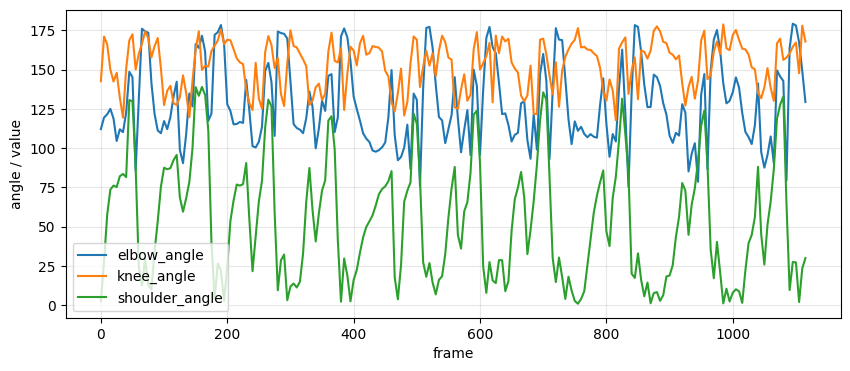

In [6]:
out_csv = COURSE_ROOT / "assets" / "results" / "d4_02_pose_angles.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
pose_df.to_csv(out_csv, index=False)
print("saved:", out_csv)

plot_angle_series(
    pose_df,
    ["elbow_angle", "knee_angle", "shoulder_angle"],
    output_path=COURSE_ROOT / "assets" / "results" / "d4_02_pose_angle_plot.png",
)

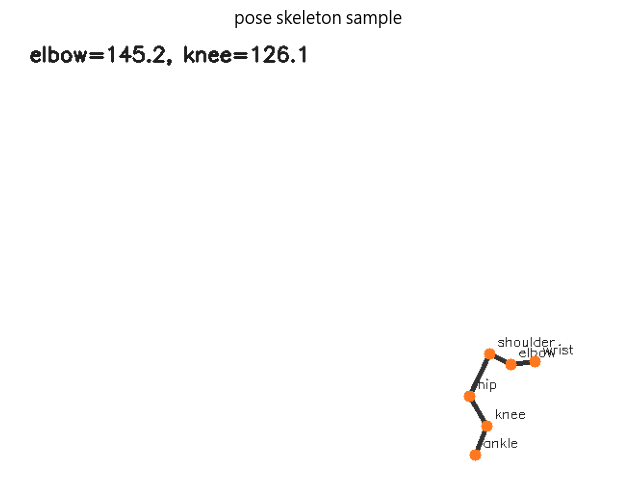

WindowsPath('H:/Repos/basketball-hackathon-course/assets/results/d4_02_pose_skeleton_sample.png')

In [7]:
# 顯示其中一個 frame 的骨架圖。
row = pose_df.iloc[len(pose_df) // 2]
img = draw_skeleton(640, 480, row)
show_image(img, "pose skeleton sample")
save_image_rgb(
    COURSE_ROOT / "assets" / "results" / "d4_02_pose_skeleton_sample.png", img
)

課堂操作：若分析對象為左手投籃，MediaPipe 區塊需將 `RIGHT_*` 改為 `LEFT_*`。

## 本單元產出檔案

- `assets/results/d4_02_pose_angles.csv`：逐 frame 的姿態角度資料。
- `assets/results/d4_02_pose_angle_plot.png`：角度變化折線圖。
- `assets/results/d4_02_pose_skeleton_sample.png`：姿態骨架示意圖。
